# Import Data

In [2]:
import sklearn as sk
import pandas as pd
import numpy as np
df = pd.read_parquet("basic_processed_data.parquet")
print(df.columns.to_list())

['Severity', 'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Street', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight', 'Duration_Minutes', 'Start_Hour', 'Start_DayOfWeek', 'Start_Month']


# Regression Target

In [3]:
df['Severity'] = df['Severity'].astype(float) * 10
y = df['Severity']
X = df.copy().drop(columns=['Severity'])

# Part III.1: Perform 10-Fold Cross Validation 

## Advanced Preprocessing

In [4]:
import numpy as np


def add_road_type(f):
    hwy_re = (
        r'\b[A-Z]{1,2}-\d+'
        r'|\b(?:Hwy|Fwy|Expy|Pkwy|Tpke|Turnpike|Highway|Freeway|Expressway|Interstate|Route|Rte|SR)\b'
    )
    local_re = (
        r'\b(?:St|Street|Rd|Road|Ave|Avenue|Blvd|Boulevard|Ln|Lane|Dr|Drive|'
        r'Ct|Court|Pl|Place|Way|Pike|Cir|Circle|Trl|Trail|Ter|Terrace)\b'
    )

    street = f['Street']
    f['road_type'] = np.select(
        [
            street.isna(),
            street.str.contains(hwy_re, regex=True, na=False),
            street.str.contains(local_re, regex=True, na=False),
        ],
        [None, 'highway', 'local_street'],
        default='other',
    )
    return f


def weather_type(cond):
    if pd.isna(cond):
        return np.nan
    if 'Fair' in cond or cond == 'Clear':
        return 'clear'
    if 'Thunder' in cond or 'T-Storm' in cond:
        return 'storm'
    if any(term in cond for term in ('Rain', 'Drizzle', 'Precipitation', 'Showers')):
        return 'rain'
    if cond == 'Wintry Mix' or 'Snow' in cond:
        return 'snow'
    if 'Cloudy' in cond or cond == 'Cloudy' or 'Clouds' in cond or 'Overcast' in cond:
        return 'cloudy'
    if any(term in cond for term in ('Fog', 'Mist', 'Smoke', 'Haze', 'Dust', 'Sand')):
        return 'low-visibility'
    if any(term in cond for term in ('Sleet', 'Hail', 'Ice Pellets', 'Tornado')):
        return 'storm'
    if 'Windy' in cond or 'Squall' in cond:
        return 'windy'
    return 'cloudy'


def add_rush_hour(hour):
    return int((7 <= hour <= 9) or (16 <= hour <= 19))


def add_wind_direction_features(F):
    direction_degrees = {
        'N': 0.0,
        'NNE': 22.5,
        'NE': 45.0,
        'ENE': 67.5,
        'E': 90.0,
        'ESE': 112.5,
        'SE': 135.0,
        'SSE': 157.5,
        'S': 180.0,
        'SSW': 202.5,
        'SW': 225.0,
        'WSW': 247.5,
        'W': 270.0,
        'WNW': 292.5,
        'NW': 315.0,
        'NNW': 337.5,
        'NORTH': 0.0,
        'EAST': 90.0,
        'SOUTH': 180.0,
        'WEST': 270.0,
    }

    direction = F['Wind_Direction'].astype('string').str.strip().str.upper()
    degrees = direction.map(direction_degrees).astype('float64')
    radians = np.deg2rad(degrees)
    calm = direction.eq('CALM').fillna(False)
    variable = direction.isin(['VAR', 'VARIABLE', 'VRB']).fillna(False)

    F['Wind_Direction_sin'] = np.sin(radians).fillna(0.0)
    F['Wind_Direction_cos'] = np.cos(radians).fillna(0.0)
    F['Wind_Direction_calm'] = calm.astype('boolean')
    F['Wind_Direction_variable'] = variable.astype('boolean')

    return F.drop(columns=['Wind_Direction'])

In [5]:
def add_grouped_features(F):
    poi_type_groups = {
        'traffic_controlled': ['Traffic_Signal', 'Stop', 'Give_Way'],
        'junctions': ['Junction', 'Roundabout', 'No_Exit'],
        'traffic_calming': ['Bump', 'Traffic_Calming'],
        'pedestrians': ['Crossing', 'Station', 'Amenity'],
    }

    for name, cols in poi_type_groups.items():
        F[name] = F[cols].fillna(False).astype(bool).any(axis=1).astype(int)
    F = F.drop(columns=[col for cols in poi_type_groups.values() for col in cols])

    F = add_road_type(F)
    F = F.drop(columns=['Street'])
    F['tod_lighting'] = np.select(
        [F['Sunrise_Sunset'] == 'Day', F['Civil_Twilight'] == 'Day'],
        ['day', 'twilight'],
        default='night',
    )
    return F.drop(
        columns=['Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']
    )

In [6]:
def add_weather_and_time_features(F):
    F['Weather_Condition'] = F['Weather_Condition'].apply(weather_type)

    # F['Start_Time'] = pd.to_datetime(F['Start_Time'], format='ISO8601')
    # F['End_Time'] = pd.to_datetime(F['End_Time'], format='ISO8601')
    # F['Duration_Minutes'] = (F['End_Time'] - F['Start_Time']).dt.total_seconds() / 60.0
    # F['Start_Hour'] = F['Start_Time'].dt.hour
    F['rush_hour'] = F['Start_Hour'].apply(add_rush_hour)
    # F['Start_DayOfWeek'] = F['Start_Time'].dt.dayofweek
    # F['Start_Month'] = F['Start_Time'].dt.month
    return F

In [7]:
def encode_and_clean_advanced(F):
    
    F = add_wind_direction_features(F)

    category_codes = {
        'Weather_Condition': {
            'clear': 0,
            'cloudy': 1,
            'rain': 2,
            'snow': 3,
            'storm': 4,
            'low-visibility': 5,
            'windy': 6,
        },
        'road_type': {
            'highway': 0,
            'local_street': 1,
            'other': 2,
        },
        'tod_lighting': {
            'day': 0,
            'twilight': 1,
            'night': 2,
        },
    }
    for column, mapping in category_codes.items():
        F[column] = F[column].map(mapping).fillna(-1).astype('int8')

    numeric_columns = F.select_dtypes(include=['number', 'bool']).columns
    for column in numeric_columns:
        missing = F[column].isna()
        if missing.any():
            fill_value = F[column].median()
            if pd.isna(fill_value):
                fill_value = 0
            F[column] = F[column].fillna(fill_value)

    return F

In [8]:
def advanced_preprocessing(fold):
    F = fold.copy()
    F = add_grouped_features(F)
    F = add_weather_and_time_features(F)
    return encode_and_clean_advanced(F)

# print(df.columns.to_list())
# df = advanced_preprocessing(df)
# print(df.columns.to_list())

# Regression Techniques

In [9]:
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import FunctionTransformer, Pipeline
from sklearn.preprocessing import OneHotEncoder



def perform_cv(Model, X, y):
    kf = KFold(n_splits=10, shuffle=True, random_state=1) 

    scoring_metrics = ["neg_mean_squared_error", "neg_root_mean_squared_error", "neg_mean_absolute_error", "r2"]

    cat_cols = make_column_selector(dtype_include=object)
    num_cols = make_column_selector(dtype_exclude=object)

    # don't impute for anything but linear regression???
    encode = ColumnTransformer([
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore"))]), 
        cat_cols),
        ("num", SimpleImputer(strategy="median"), num_cols),
    ])

    pipe = Pipeline([
        ("prep", FunctionTransformer(advanced_preprocessing)),
        ("encode", encode),
        ("model", Model),
    ])

    res = cross_validate(pipe, X, y, cv=kf, scoring=scoring_metrics)
    return res


## Dummy Regressor

In [10]:
from sklearn.dummy import DummyRegressor

dr = DummyRegressor(strategy='mean')

Xs = X.sample(200_000, random_state=1)
ys = y.loc[Xs.index]

print(df.columns.to_list())

res = perform_cv(dr, Xs, ys)

print(res)

['Severity', 'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Street', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight', 'Duration_Minutes', 'Start_Hour', 'Start_DayOfWeek', 'Start_Month']
{'fit_time': array([1.055866  , 0.73495626, 0.72684383, 0.73269415, 0.73026323,
       0.70522165, 0.7080195 , 0.70493937, 0.70928597, 0.71426654]), 'score_time': array([0.05843496, 0.05297709, 0.05787301, 0.05388618, 0.05173326,
       0.05308008, 0.05259681, 0.05367732, 0.05544734, 0.05024314]), 'test_neg_mean_squared_error': array([-15.68815783, -16.67601821, -16.07080746, -16.63210917,
       -15.53451709, -16.6963088 , -15.6668506 , -16.7166162

## Linear Regression

In [11]:
from sklearn.linear_model import LinearRegression

Xs = X.sample(200_000, random_state=1)
ys = y.loc[Xs.index]

print("Start_Time" in Xs.columns)


lr = LinearRegression()
res = perform_cv(lr, Xs, ys)

print(res)

False
{'fit_time': array([0.8139534 , 0.78453279, 0.77853417, 0.75062466, 0.76719427,
       0.7754662 , 0.78175187, 0.75329041, 0.77233863, 0.75089407]), 'score_time': array([0.05175281, 0.05331993, 0.05327129, 0.06070828, 0.05042744,
       0.05232286, 0.05128503, 0.05092359, 0.04906607, 0.04679942]), 'test_neg_mean_squared_error': array([-15.36108967, -16.33026722, -15.71466903, -16.21832236,
       -15.19875621, -16.30185211, -15.30806033, -16.35566584,
       -16.2325443 , -16.16721971]), 'test_neg_root_mean_squared_error': array([-3.9193226 , -4.04107253, -3.96417318, -4.02719783, -3.89855822,
       -4.03755521, -3.91255164, -4.04421387, -4.02896318, -4.02084813]), 'test_neg_mean_absolute_error': array([-1.70890173, -1.75915691, -1.72964509, -1.75188107, -1.70102795,
       -1.76200905, -1.70686461, -1.75870419, -1.75198785, -1.74421284]), 'test_r2': array([0.02081727, 0.02066598, 0.02215307, 0.02487226, 0.02135222,
       0.02358205, 0.02285311, 0.02156758, 0.02197939, 0.022374

## Regression Trees


In [12]:
from sklearn.tree import DecisionTreeRegressor

dtr1 = DecisionTreeRegressor(random_state=False)
dtr2 = DecisionTreeRegressor(max_depth=5, random_state=False)

Xs = X.sample(200_000, random_state=1)
ys = y.loc[Xs.index]
res1 = perform_cv(dtr1, Xs, ys)
res2 = perform_cv(dtr2, Xs, ys)

print(res1)
print('\n')
print(res2)

KeyboardInterrupt: 

## Random Forests

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rfr1 = RandomForestRegressor()
rfr2 = RandomForestRegressor(max_depth=5)

Xs = X.sample(10_000, random_state=1)
ys = y.loc[Xs.index]

res1 = perform_cv(rfr1, Xs, ys)
res2 = perform_cv(rfr2, Xs, ys)

print(res1)
print(res2)

{'fit_time': array([211.80011225, 269.88652611, 267.56937194, 170.8075254 ,
       263.22208166, 271.49069667, 275.60121679, 272.74151969,
       251.41645074, 249.18639016]), 'score_time': array([0.51328993, 0.51366544, 0.25804973, 0.27514338, 0.51038599,
       0.49560571, 0.52652287, 0.55372   , 0.47489643, 0.46544981]), 'test_neg_mean_squared_error': array([-12.14873096, -12.58849679, -12.50976314, -12.75188887,
       -12.08713328, -13.10963989, -11.96401308, -12.89431893,
       -12.58032536, -12.27568087]), 'test_neg_root_mean_squared_error': array([-3.48550297, -3.54802717, -3.53691435, -3.5709787 , -3.47665547,
       -3.62072367, -3.45890345, -3.59086604, -3.54687544, -3.50366677]), 'test_neg_mean_absolute_error': array([-1.33288857, -1.3653901 , -1.36474105, -1.38286826, -1.34310832,
       -1.41234762, -1.34766417, -1.38613746, -1.36748865, -1.34996632]), 'test_r2': array([0.225587  , 0.24506176, 0.22157867, 0.23329181, 0.2217096 ,
       0.21478322, 0.23631094, 0.22863308,

# Part III.2: Final Regression Model

In [ ]:

dtr = DecisionTreeRegressor(max_depth=5, random_state=False)
res1 = perform_cv(dtr, X, y)
print(res1)


{'fit_time': array([32.70089555, 32.04846859, 31.6221602 , 41.65225625, 38.60351515,
       32.34766078, 33.01168895, 32.08526969, 42.20071459, 41.55214858]), 'score_time': array([0.81716943, 0.8313005 , 0.82878494, 1.22123575, 0.8520329 ,
       0.8386147 , 0.81245255, 1.07514644, 1.05478978, 1.03598213]), 'test_neg_mean_squared_error': array([-14.32552665, -14.32489858, -14.22660814, -14.30353483,
       -14.45327613, -14.40904325, -14.53366112, -14.31306537,
       -14.36347458, -14.41575433]), 'test_neg_root_mean_squared_error': array([-3.78490775, -3.78482478, -3.77181762, -3.78200143, -3.80174646,
       -3.79592456, -3.81230391, -3.78326121, -3.78991749, -3.79680844]), 'test_neg_mean_absolute_error': array([-1.52035011, -1.52307933, -1.51592256, -1.52367907, -1.52860827,
       -1.52471546, -1.53382896, -1.52170166, -1.52352787, -1.52959952]), 'test_r2': array([0.1279522 , 0.12976312, 0.128925  , 0.12909228, 0.12931392,
       0.12465168, 0.12788191, 0.12953743, 0.13090257, 0.13

In [ ]:
import matplotlib.pyplot as plt
def visualize_tree(classifier, feature_names, label="Unlabeled", class_names=['Low', 'Moderate', 'High']):
    plt.figure(figsize=(50, 18))
    sk.tree.plot_tree(
        classifier,
        filled=True,
        feature_names=feature_names,
        class_names=class_names,
        rounded=True,
        fontsize=8,
    )
    plt.title(f"Regression Tree Visualization: {label}")


def plot_tree_panel(data, target, settings, title, figsize=(16, 6), display_depth=3):
    fig, axes = plt.subplots(1, len(settings), figsize=figsize, squeeze=False)

    for (setting_name, parameters), ax in zip(settings, axes.flat):
        classifier = sk.tree.DecisionTreeRegressor(random_state=42, **parameters)
        classifier.fit(data, target)
        sk.tree.plot_tree(
            classifier,
            filled=True,
            feature_names=data.columns,
            class_names=['Low', 'Moderate', 'High'],
            rounded=True,
            fontsize=8,
            max_depth=display_depth,
            ax=ax,
        )
        ax.set_title(f"{setting_name}\n{classifier.tree_.node_count} total nodes")

    fig.suptitle(f"{title} (showing top {display_depth} levels)", fontsize=16)
    plt.tight_layout()
    plt.show()


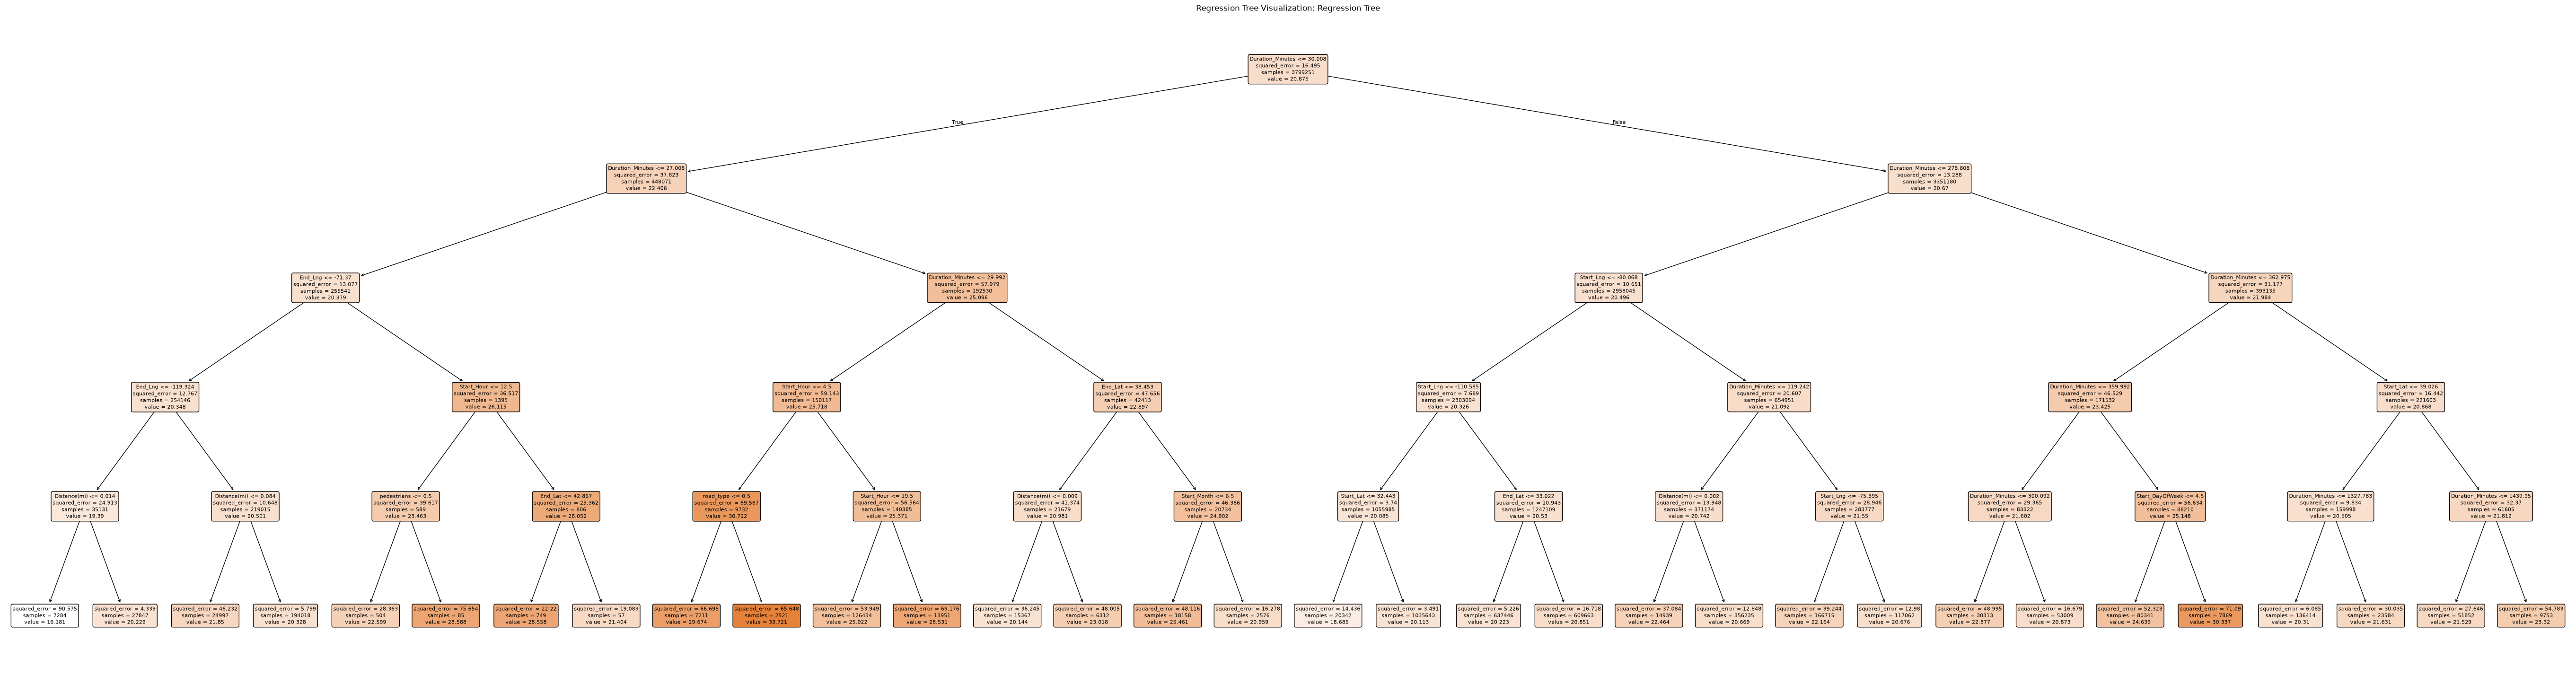

In [31]:
# 1. Apply the advanced preprocessing to the ENTIRE dataset
Xp = advanced_preprocessing(X)

# 2. Make everything numeric and fill any leftover NaNs (same median imputation as the CV pipeline)
Xp = Xp.astype(float)
Xp = Xp.fillna(Xp.median())

# 3. Fit the final tree
newdtr = DecisionTreeRegressor(max_depth=5, random_state=0)
newdtr.fit(Xp, y)

# 4. Visualize, passing the PREPROCESSED column names
visualize_tree(newdtr, Xp.columns, label="Regression Tree")